In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# 3. tratamento de valores ausentes

In [3]:
nulls = df.isnull().sum()
nulls[nulls > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

count    119386.000000
mean          0.103890
std           0.398561
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: children, dtype: float64
0.0


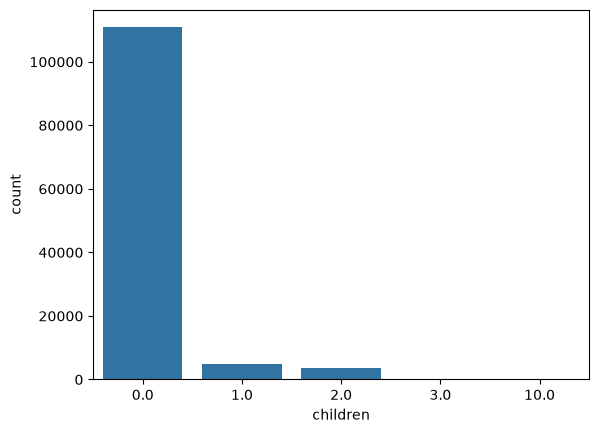

In [4]:
sns.countplot(data=df, x="children")
print(df['children'].describe())
print(df['children'].mode()[0])

In [5]:
df['children'] = df['children'].fillna(0)
df['children'].isnull().sum()

np.int64(0)

In [6]:
print(df['country'].count())
print(df['country'].isnull().sum())

118902
488


<Axes: xlabel='country'>

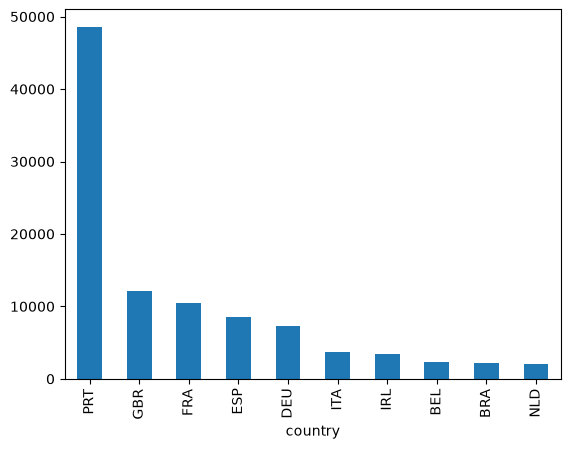

In [7]:
top = df['country'].value_counts().head(10)
top.plot(kind='bar')

In [8]:
df['country'] = df['country'].fillna('PRT')
df['country'].isnull().sum()

np.int64(0)

# questões
1. Quais dois atributos foram escolhidos e qual estratégia foi utilizada para tratar os valores ausentes de cada um?
 - foi escolhido 'country' e 'children', e a estrategia utilizada foi substituir pela moda
2. Quantos valores ausentes foram eliminados ou substituídos após o tratamento?
 - foram tratados 488 em country e 4 em children
3. Por que a estratégia escolhida é adequada para cada atributo?
 - country: por ser um atributo com pouquissimos valores nulos proporcionais ~0.4% do total, substituir pelo valor mais frequente nao vai alterar o padão pedrominante
 - children: mesma justificativa da anterior, com menos ainda ~0.003% dos totais, e >90% das reservas tinham 0 crianças, então é justificável trocar por 0

# 4. remocao de registros duplicados

In [9]:
df.duplicated().sum()

np.int64(32013)

In [10]:
df = df.drop_duplicates()

# questões 
1. Quantos registros foram removidos e quantas instâncias permanecem no conjunto após a remoção?
 - tinham 32.013 instancias duplicadas, restaram 87.377 instancias

# 5. criação e transformação de atributos

In [11]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [12]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

df['stay_length'] = pd.cut(
    df['total_nights'], 
    bins=[0, 2, 5, float('inf')], 
    labels=['curta', 'media', 'longa'],
    right=True
)

df['stay_length'].value_counts()

stay_length
media    38151
curta    32915
longa    15660
Name: count, dtype: int64

In [13]:
df.groupby('stay_length')['adr'].describe()

,count,mean,std,min,25%,50%,75%,max
stay_length,,,,,,,,
curta,32915.0,101.099516,58.720846,0.00,65.8300,94.59,129.00,5400.0
media,38151.0,110.951108,48.586229,0.00,78.0000,103.50,135.15,402.0
longa,15660.0,110.570271,57.323309,-6.38,69.0975,98.36,141.46,450.0


<Axes: xlabel='stay_length', ylabel='adr'>

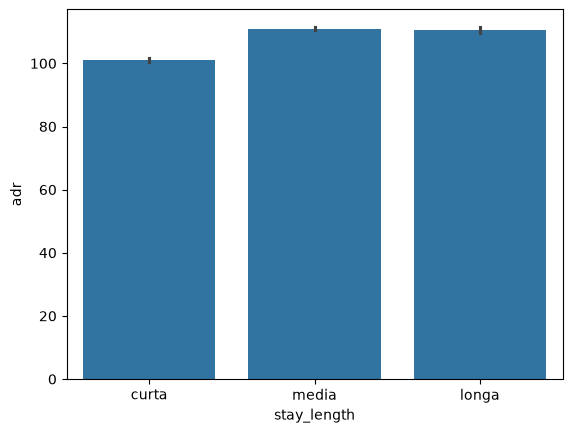

In [14]:
sns.barplot(data=df, x='stay_length', y='adr')

# questões
5. Quantas reservas pertencem a cada categoria de stay_length?
 - curta = 32915
 - média = 38151
 - longa = 15660
7. Qual categoria representa a maior parte das reservas?
 - média
8. Compare a distribuição de adr entre as três categorias de duração. Qual grupo apresenta o maior ADR médio?
 - a categoria média

# 6. normalização

In [15]:
df['adr_normalized'] = ((df['adr'] - df['adr'].min()) / (df['adr'].max() - df['adr'].min()))
 
df['adr_normalized'].describe()

count    87377.000000
mean         0.020850
std          0.010174
min          0.000000
25%          0.014498
50%          0.019325
75%          0.025966
max          1.000000
Name: adr_normalized, dtype: float64

# questões
8. Após a normalização, qual é o menor e o maior valor de adr_normalized? Explique o que significa transformar o atributo adr para essa nova escala.
 - a normalização mapeia os valores de adr para uma nova escala entre 0 e 1, com a proporcao entre eles, o maior vai ser mapeado para 1.0 e o menor para 0.0

# 7. comparação final

In [16]:
old_df = pd.read_csv("hotel_bookings.csv")

comparison = pd.DataFrame({
    "Característica": [
        "Número de instâncias",
        "Número de atributos",
        "Valores ausentes nos atributos escolhidos (country + children)",
        "Registros duplicados"
    ],
    "Antes": [
        old_df.shape[0],
        old_df.shape[1],
        old_df['country'].isnull().sum() + df['children'].isnull().sum(),
        old_df.duplicated().sum()
    ],
    "Depois": [
        df.shape[0],
        df.shape[1],
        df['country'].isnull().sum() + df['children'].isnull().sum(),
        df.duplicated().sum()
    ]
})

print(comparison.to_string(index=False))


                                                Característica  Antes  Depois
                                          Número de instâncias 119390   87377
                                           Número de atributos     32      35
Valores ausentes nos atributos escolhidos (country + children)    488       0
                                          Registros duplicados  31994       0


O que foi necessário modificar nos dados para que eles estivessem mais adequados para uma etapa posterior de Mineração de Dados?
 - tratamentos de dados incompletos/faltantes, com substituicacao por valores coerente
 - eliminacao de redundancia, com a remocao de mais de 32 mil registros duplicados
 - criacao de outra feature total_nights para a realizacao de uma categorizacao/discretizacao facilitando a extracao de padroe
 - padronizacao de escala, na normalizacao de adr para o intervalo [0,1]